# Research Question 3: Tyre Strategy Optimization

**ST312 Project - Candidates: 60276, 61881**

## Research Question
*"How do tyre compound choices, degradation patterns, and pit stop timing affect race performance across different circuit characteristics and driver profiles?"*

## Context
Tyre strategy is one of the few controllable variables during F1 races. Teams must balance:
- **Compound choice**: Soft (fast, high degradation) vs Medium vs Hard (slow, low degradation)
- **Stint length**: When to pit for fresh tyres
- **Track conditions**: Temperature, circuit characteristics
- **Driver style**: Some drivers manage tyres better than others

## Note
This research question may be removed or modified based on data availability and project scope. If included, it will build on RQ1 and RQ2 findings.

## Approach
This notebook focuses on **exploratory data analysis** through visualization:
- Load tyre compound and lap time data for 2022-2024
- Visualize lap time degradation by compound type
- Analyze optimal stint lengths
- Compare compound performance across circuit types
- Identify driver-specific tyre management patterns

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Import custom utilities
import data_utils as du

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Data Loading

Load tyre compound, lap time, and circuit data for 2022-2024 seasons.

In [2]:
# Define years to analyze
YEARS = [2022, 2023, 2024]

# Load tyre strategy data (uses same data as RQ2)
print("Loading tyre strategy data...")
print("Note: This uses cached data from RQ2 if available.\n")

tyre_df = du.load_tyre_strategy_data(YEARS)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loading tyre strategy data...
Note: This uses cached data from RQ2 if available.


Loading 2022 season lap data...
  Processing Bahrain Grand Prix... 

req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 16 completed the race distance 00:00.050000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '44', '63', '20', '77', '31', '22', '14', '24', '47', '18', '23', '3', '4', '6', '27', '11', '1', '10']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 22
core  

✓
  Processing Saudi Arabian Grand Prix... 

core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 22)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 47)
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '55', '11', '63', '31', '4', '10', '20', '44', '24', '27', '18', '23', '77', '14', '3', '6', '22', '47']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core       

...

✓
  Processing Qatar Grand Prix... 

core        WARNING 	Fixed incorrect tyre stint information for driver '43'
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '81', '63', '10', '55', '14', '24', '20', '4', '77', '44', '22', '30', '23', '27', '11', '18', '43', '31']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


✓
  Processing Abu Dhabi Grand Prix... 

req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '55', '16', '44', '63', '1', '10', '27', '14', '81', '23', '22', '24', '18', '61', '20', '30', '77', '43', '11']


✓

Loaded 64479 lap observations


In [3]:
# Display data summary
du.print_data_summary(tyre_df, "RQ3: Tyre Strategy Data Summary")

print("\nTyre Compound Distribution:")
print(tyre_df['compound'].value_counts())

print("\nCircuit Type Distribution:")
print(tyre_df['circuit_type'].value_counts())

print("\nSample data:")
tyre_df.head(10)


RQ3: Tyre Strategy Data Summary
Total observations: 64479
Date range: 2022 - 2024
Number of unique races: 25
Number of unique drivers: 28
Number of unique teams: 12


Tyre Compound Distribution:
compound
HARD            29919
MEDIUM          22775
SOFT             7672
INTERMEDIATE     3476
None              330
WET               307
Name: count, dtype: int64

Circuit Type Distribution:
circuit_type
technical     39908
street        15561
high_speed     9010
Name: count, dtype: int64

Sample data:


,year,race,driver,team,lap_number,lap_time,compound,tyre_life,stint,track_status,is_personal_best,circuit_type
0,2022,Bahrain Grand Prix,VER,Red Bull Racing,2.0,97.880,SOFT,5.0,1.0,1,True,technical
1,2022,Bahrain Grand Prix,VER,Red Bull Racing,3.0,98.357,SOFT,6.0,1.0,1,False,technical
2,2022,Bahrain Grand Prix,VER,Red Bull Racing,4.0,98.566,SOFT,7.0,1.0,1,False,technical
3,2022,Bahrain Grand Prix,VER,Red Bull Racing,5.0,98.877,SOFT,8.0,1.0,1,False,technical
4,2022,Bahrain Grand Prix,VER,Red Bull Racing,6.0,98.940,SOFT,9.0,1.0,1,False,technical
5,2022,Bahrain Grand Prix,VER,Red Bull Racing,7.0,99.062,SOFT,10.0,1.0,1,False,technical
6,2022,Bahrain Grand Prix,VER,Red Bull Racing,8.0,99.092,SOFT,11.0,1.0,1,False,technical
7,2022,Bahrain Grand Prix,VER,Red Bull Racing,9.0,99.251,SOFT,12.0,1.0,1,False,technical
8,2022,Bahrain Grand Prix,VER,Red Bull Racing,10.0,99.392,SOFT,13.0,1.0,1,False,technical
9,2022,Bahrain Grand Prix,VER,Red Bull Racing,11.0,99.479,SOFT,14.0,1.0,1,False,technical


## 2. Tyre Degradation Analysis

Analyze how lap times degrade as tyres age (tyre life increases).

In [4]:
# Filter to valid lap times and tyre life data
valid_tyre_df = tyre_df[
    (tyre_df['lap_time'].notna()) & 
    (tyre_df['tyre_life'].notna()) &
    (tyre_df['tyre_life'] > 0) &
    (tyre_df['tyre_life'] <= 40)  # Exclude outliers
].copy()

print(f"Valid tyre degradation observations: {len(valid_tyre_df):,}")
print(f"\nTyre life range: {valid_tyre_df['tyre_life'].min():.0f} - {valid_tyre_df['tyre_life'].max():.0f} laps")

Valid tyre degradation observations: 62,691

Tyre life range: 2 - 40 laps


In [5]:
# Calculate average lap time by tyre age and compound
degradation_analysis = valid_tyre_df.groupby(['compound', 'tyre_life'])['lap_time'].agg(['mean', 'std', 'count']).reset_index()

# Filter to compounds with sufficient data
main_compounds = degradation_analysis.groupby('compound')['count'].sum()
main_compounds = main_compounds[main_compounds > 100].index.tolist()

print(f"Compounds with sufficient data: {', '.join(main_compounds)}")

degradation_filtered = degradation_analysis[degradation_analysis['compound'].isin(main_compounds)]

Compounds with sufficient data: HARD, INTERMEDIATE, MEDIUM, SOFT, WET


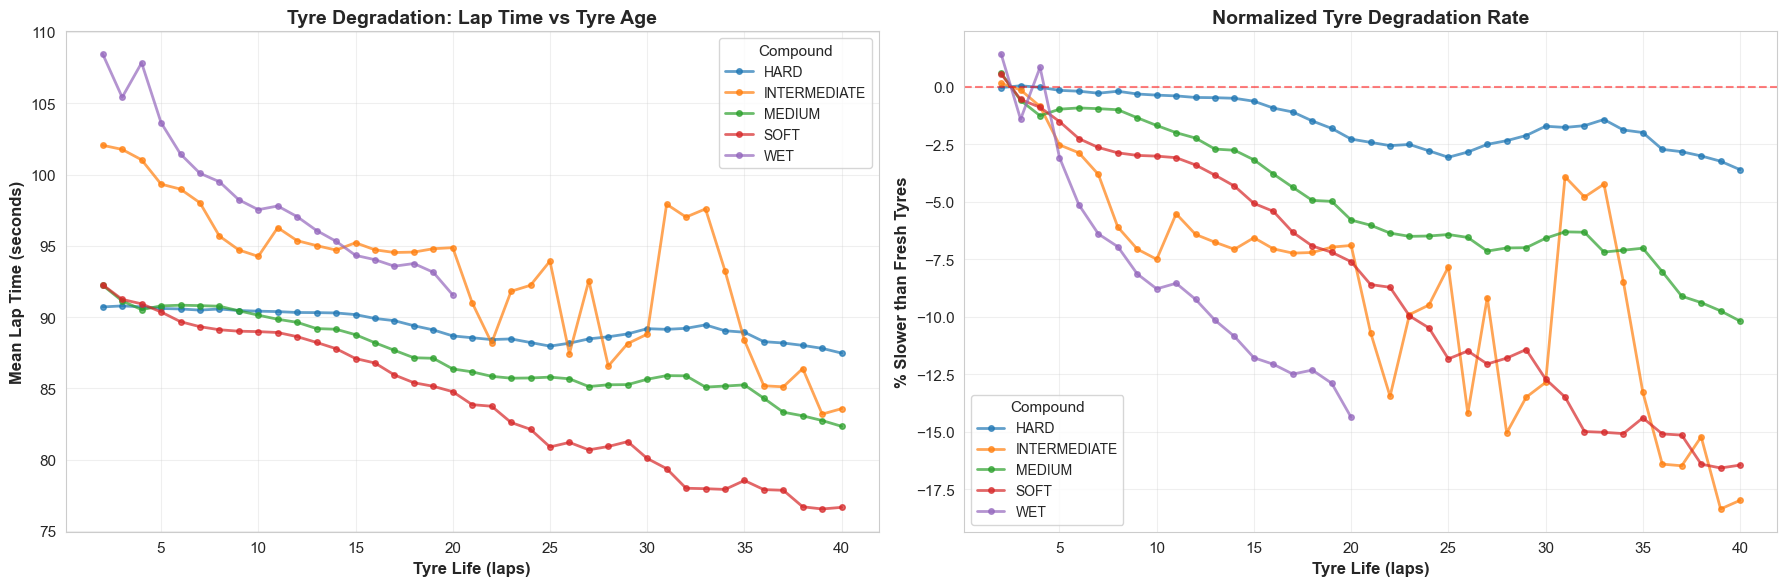

In [6]:
# Visualize degradation curves by compound
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Mean lap time vs tyre age
for compound in main_compounds:
    compound_data = degradation_filtered[degradation_filtered['compound'] == compound]
    ax1.plot(compound_data['tyre_life'], compound_data['mean'], 
             marker='o', linewidth=2, markersize=4, label=compound, alpha=0.7)

ax1.set_xlabel('Tyre Life (laps)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Lap Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Tyre Degradation: Lap Time vs Tyre Age', fontsize=14, fontweight='bold')
ax1.legend(title='Compound', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Normalized degradation (% slower than lap 1)
for compound in main_compounds:
    compound_data = degradation_filtered[degradation_filtered['compound'] == compound].copy()
    baseline = compound_data[compound_data['tyre_life'] <= 3]['mean'].mean()  # First 3 laps baseline
    
    if baseline > 0:
        compound_data['pct_slower'] = ((compound_data['mean'] - baseline) / baseline) * 100
        ax2.plot(compound_data['tyre_life'], compound_data['pct_slower'], 
                marker='o', linewidth=2, markersize=4, label=compound, alpha=0.7)

ax2.set_xlabel('Tyre Life (laps)', fontsize=12, fontweight='bold')
ax2.set_ylabel('% Slower than Fresh Tyres', fontsize=12, fontweight='bold')
ax2.set_title('Normalized Tyre Degradation Rate', fontsize=14, fontweight='bold')
ax2.legend(title='Compound', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [7]:
# Calculate degradation rates (slope) for each compound
degradation_rates = []

for compound in main_compounds:
    compound_data = degradation_filtered[degradation_filtered['compound'] == compound]
    
    if len(compound_data) > 5:  # Need sufficient points for regression
        # Linear regression: lap_time ~ tyre_life
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            compound_data['tyre_life'], compound_data['mean']
        )
        
        degradation_rates.append({
            'Compound': compound,
            'Degradation Rate (sec/lap)': f"{slope:.4f}",
            'R²': f"{r_value**2:.3f}",
            'P-value': f"{p_value:.2e}",
            'Observations': compound_data['count'].sum()
        })

deg_rate_df = pd.DataFrame(degradation_rates)

print("\nTyre Degradation Rates")
print("="*80)
print("Higher values = faster degradation (lap time increases more per lap)")
print(deg_rate_df.to_string(index=False))


Tyre Degradation Rates
Higher values = faster degradation (lap time increases more per lap)
    Compound Degradation Rate (sec/lap)    R²  P-value  Observations
        HARD                    -0.0766 0.753 8.42e-13         28799
INTERMEDIATE                    -0.3440 0.611 4.17e-09          3453
      MEDIUM                    -0.2284 0.943 1.51e-24         22412
        SOFT                    -0.4269 0.985 1.99e-35          7660
         WET                    -0.8537 0.917 1.26e-10           307


## 3. Optimal Stint Length Analysis

Determine how long drivers typically run on each compound and what appears optimal.

In [8]:
# Calculate stint lengths by compound
stint_data = valid_tyre_df.groupby(['driver', 'race', 'stint', 'compound']).agg({
    'tyre_life': 'max',
    'lap_time': 'mean'
}).reset_index()

stint_data.columns = ['driver', 'race', 'stint', 'compound', 'stint_length', 'avg_lap_time']

# Filter to main compounds
stint_data = stint_data[stint_data['compound'].isin(main_compounds)]

print("Stint Length Statistics by Compound")
print("="*80)
print(stint_data.groupby('compound')['stint_length'].describe())

Stint Length Statistics by Compound
              count       mean        std  min   25%   50%   75%   max
compound                                                              
HARD          866.0  27.011547   9.903691  2.0  19.0  27.0  36.0  40.0
INTERMEDIATE  231.0  18.424242  10.159259  2.0  10.0  17.0  24.0  40.0
MEDIUM        974.0  20.553388   8.593045  2.0  14.0  19.0  26.0  40.0
SOFT          474.0  16.805907   7.506747  2.0  12.0  17.0  22.0  40.0
WET            37.0  10.675676   6.476685  3.0   4.0   8.0  17.0  20.0


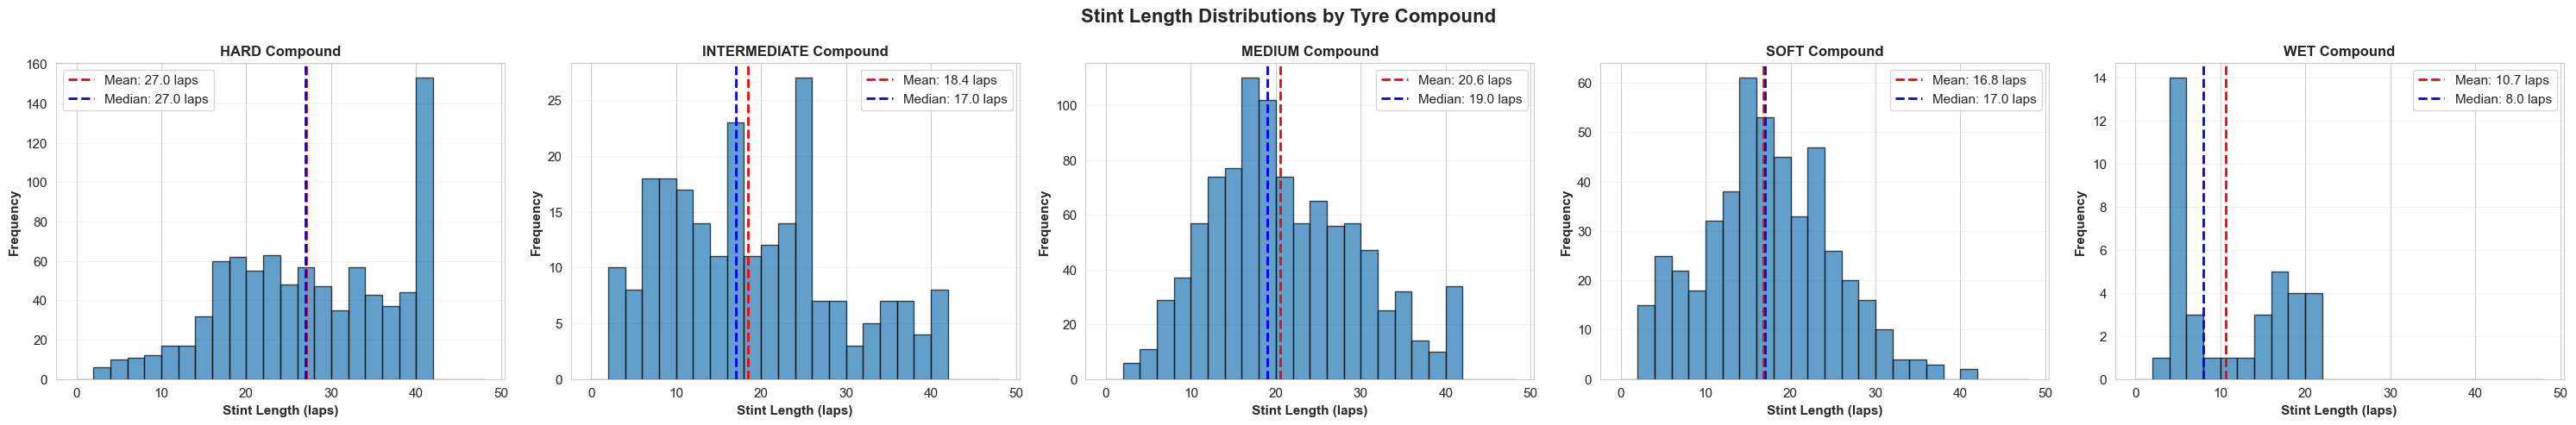

In [9]:
# Visualize stint length distributions
fig, axes = plt.subplots(1, len(main_compounds), figsize=(6*len(main_compounds), 5))

if len(main_compounds) == 1:
    axes = [axes]

for idx, compound in enumerate(main_compounds):
    compound_stints = stint_data[stint_data['compound'] == compound]['stint_length']
    
    axes[idx].hist(compound_stints, bins=range(0, 50, 2), edgecolor='black', alpha=0.7)
    axes[idx].axvline(compound_stints.mean(), color='red', linestyle='--', linewidth=2,
                     label=f'Mean: {compound_stints.mean():.1f} laps')
    axes[idx].axvline(compound_stints.median(), color='blue', linestyle='--', linewidth=2,
                     label=f'Median: {compound_stints.median():.1f} laps')
    
    axes[idx].set_xlabel('Stint Length (laps)', fontweight='bold')
    axes[idx].set_ylabel('Frequency', fontweight='bold')
    axes[idx].set_title(f'{compound} Compound', fontweight='bold', fontsize=12)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Stint Length Distributions by Tyre Compound', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

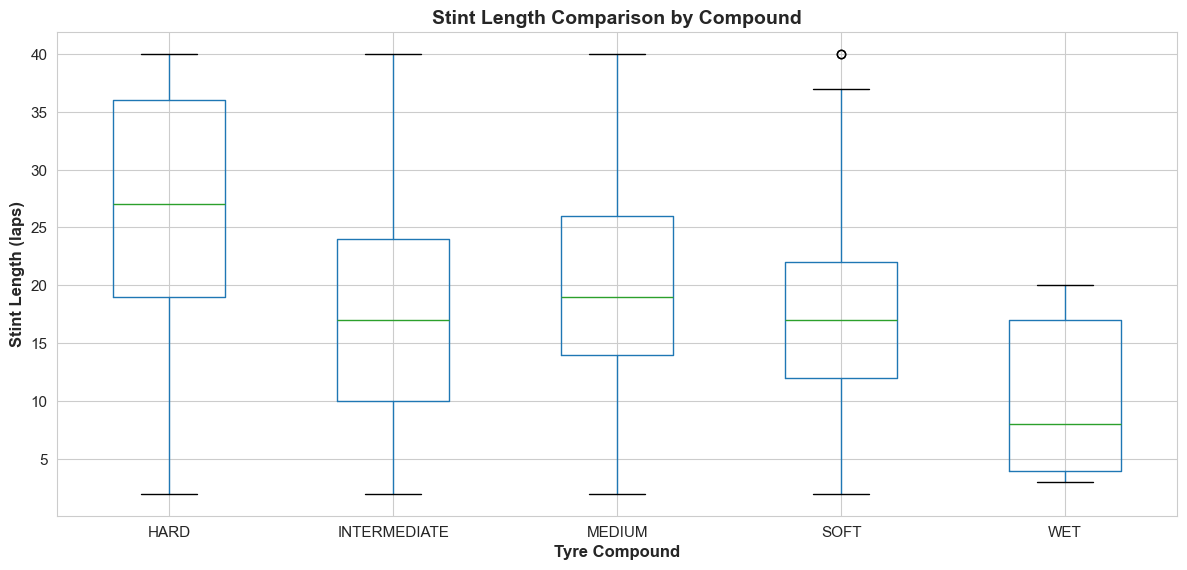

In [10]:
# Box plot comparison
fig, ax = plt.subplots(figsize=(12, 6))

stint_data.boxplot(column='stint_length', by='compound', ax=ax)
ax.set_xlabel('Tyre Compound', fontsize=12, fontweight='bold')
ax.set_ylabel('Stint Length (laps)', fontsize=12, fontweight='bold')
ax.set_title('Stint Length Comparison by Compound', fontsize=14, fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 4. Circuit-Specific Compound Performance

Analyze how compound choice varies across different circuit types.

In [11]:
# Compound usage by circuit type
circuit_compound = valid_tyre_df.groupby(['circuit_type', 'compound']).size().reset_index(name='laps')

# Calculate percentage within each circuit type
total_per_circuit = circuit_compound.groupby('circuit_type')['laps'].transform('sum')
circuit_compound['percentage'] = (circuit_compound['laps'] / total_per_circuit * 100).round(1)

print("Compound Usage by Circuit Type")
print("="*80)
print(circuit_compound.pivot(index='circuit_type', columns='compound', values='percentage').fillna(0))

Compound Usage by Circuit Type
compound      HARD  INTERMEDIATE  MEDIUM  None  SOFT  WET
circuit_type                                             
high_speed    42.3           4.0    35.7   0.3  17.4  0.3
street        57.2           5.8    31.7   0.2   3.2  1.8
technical     42.5           5.7    37.3   0.0  14.4  0.0


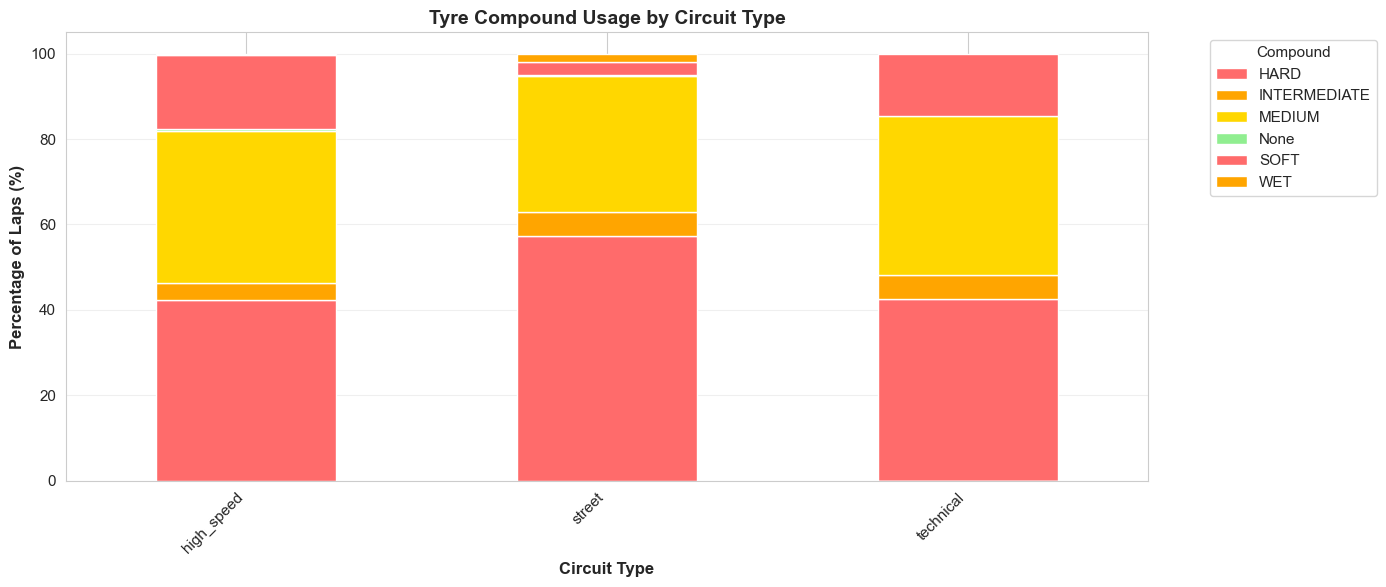

In [12]:
# Visualize compound usage by circuit type
fig, ax = plt.subplots(figsize=(14, 6))

circuit_pivot = circuit_compound.pivot(index='circuit_type', columns='compound', values='percentage').fillna(0)
circuit_pivot.plot(kind='bar', ax=ax, stacked=True, 
                   color=['#FF6B6B', '#FFA500', '#FFD700', '#90EE90'])

ax.set_xlabel('Circuit Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage of Laps (%)', fontsize=12, fontweight='bold')
ax.set_title('Tyre Compound Usage by Circuit Type', fontsize=14, fontweight='bold')
ax.legend(title='Compound', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [13]:
# Compare degradation rates by circuit type
circuit_deg_rates = []

for circuit_type in valid_tyre_df['circuit_type'].unique():
    for compound in main_compounds:
        subset = valid_tyre_df[
            (valid_tyre_df['circuit_type'] == circuit_type) & 
            (valid_tyre_df['compound'] == compound)
        ]
        
        if len(subset) > 50:  # Minimum data requirement
            # Group by tyre_life for cleaner regression
            grouped = subset.groupby('tyre_life')['lap_time'].mean().reset_index()
            
            if len(grouped) > 5:
                slope, _, r_value, _, _ = stats.linregress(grouped['tyre_life'], grouped['lap_time'])
                
                circuit_deg_rates.append({
                    'Circuit Type': circuit_type,
                    'Compound': compound,
                    'Deg Rate (s/lap)': f"{slope:.4f}",
                    'R²': f"{r_value**2:.3f}",
                    'Laps': len(subset)
                })

circuit_deg_df = pd.DataFrame(circuit_deg_rates)

if len(circuit_deg_df) > 0:
    print("\nDegradation Rates by Circuit Type and Compound")
    print("="*80)
    print(circuit_deg_df.to_string(index=False))
else:
    print("\nInsufficient data for circuit-specific degradation analysis")


Degradation Rates by Circuit Type and Compound
Circuit Type     Compound Deg Rate (s/lap)    R²  Laps
   technical         HARD          -0.2113 0.946 16751
   technical INTERMEDIATE          -0.3013 0.836  2253
   technical       MEDIUM          -0.2400 0.955 14676
   technical         SOFT          -0.4491 0.973  5677
      street         HARD          -0.1221 0.941  8370
      street INTERMEDIATE           0.3691 0.274   852
      street       MEDIUM          -0.4322 0.945  4632
      street         SOFT          -0.1391 0.232   473
      street          WET          -0.8883 0.787   269
  high_speed         HARD          -0.1040 0.494  3678
  high_speed INTERMEDIATE           0.0984 0.814   348
  high_speed       MEDIUM           0.0244 0.005  3104
  high_speed         SOFT          -0.2406 0.822  1510


## 5. Driver-Specific Tyre Management

Identify drivers who manage tyres better (slower degradation) vs those who are harder on tyres.

In [14]:
# Calculate driver-specific degradation rates
# Focus on drivers with substantial data

driver_laps = valid_tyre_df.groupby('driver').size()
main_drivers = driver_laps[driver_laps > 500].index.tolist()  # Drivers with 500+ valid laps

print(f"Drivers with sufficient data (500+ laps): {len(main_drivers)}")
print(f"Drivers: {', '.join(sorted(main_drivers)[:10])}...")

Drivers with sufficient data (500+ laps): 25
Drivers: ALB, ALO, BOT, DEV, GAS, HAM, HUL, LAT, LAW, LEC...


In [15]:
# Calculate degradation rate for each driver on soft compound
# (Soft tyres show clearest degradation patterns)

driver_deg_rates = []

for driver in main_drivers:
    driver_data = valid_tyre_df[
        (valid_tyre_df['driver'] == driver) & 
        (valid_tyre_df['compound'] == 'SOFT')
    ]
    
    if len(driver_data) > 50:
        # Group by tyre_life
        grouped = driver_data.groupby('tyre_life')['lap_time'].mean().reset_index()
        
        if len(grouped) > 5:
            slope, _, r_value, _, _ = stats.linregress(grouped['tyre_life'], grouped['lap_time'])
            
            driver_deg_rates.append({
                'Driver': driver,
                'Team': valid_tyre_df[valid_tyre_df['driver'] == driver]['team'].mode()[0],
                'Deg Rate (s/lap)': slope,
                'R²': r_value**2,
                'Soft Laps': len(driver_data)
            })

driver_deg_df = pd.DataFrame(driver_deg_rates)
driver_deg_df = driver_deg_df.sort_values('Deg Rate (s/lap)')

print("\nDriver Tyre Management: Soft Compound Degradation Rates")
print("="*80)
print("Lower rates = better tyre management (slower degradation)")
print("\nTop 10 Best Tyre Managers:")
print(driver_deg_df.head(10).to_string(index=False))

print("\nTop 10 Hardest on Tyres:")
print(driver_deg_df.tail(10).to_string(index=False))


Driver Tyre Management: Soft Compound Degradation Rates
Lower rates = better tyre management (slower degradation)

Top 10 Best Tyre Managers:
Driver            Team  Deg Rate (s/lap)       R²  Soft Laps
   HUL    Haas F1 Team         -0.902388 0.771520        240
   PIA         McLaren         -0.698680 0.693761        156
   OCO          Alpine         -0.605487 0.893574        347
   SAR        Williams         -0.567977 0.651198        246
   PER Red Bull Racing         -0.563690 0.925980        384
   VER Red Bull Racing         -0.539931 0.925715        462
   ALB        Williams         -0.526415 0.951946        323
   MSC    Haas F1 Team         -0.509606 0.784499        174
   HAM        Mercedes         -0.501511 0.932262        433
   ALO    Aston Martin         -0.493869 0.832757        358

Top 10 Hardest on Tyres:
Driver         Team  Deg Rate (s/lap)       R²  Soft Laps
   MAG Haas F1 Team         -0.414312 0.668856        221
   TSU   AlphaTauri         -0.399954 0.5546

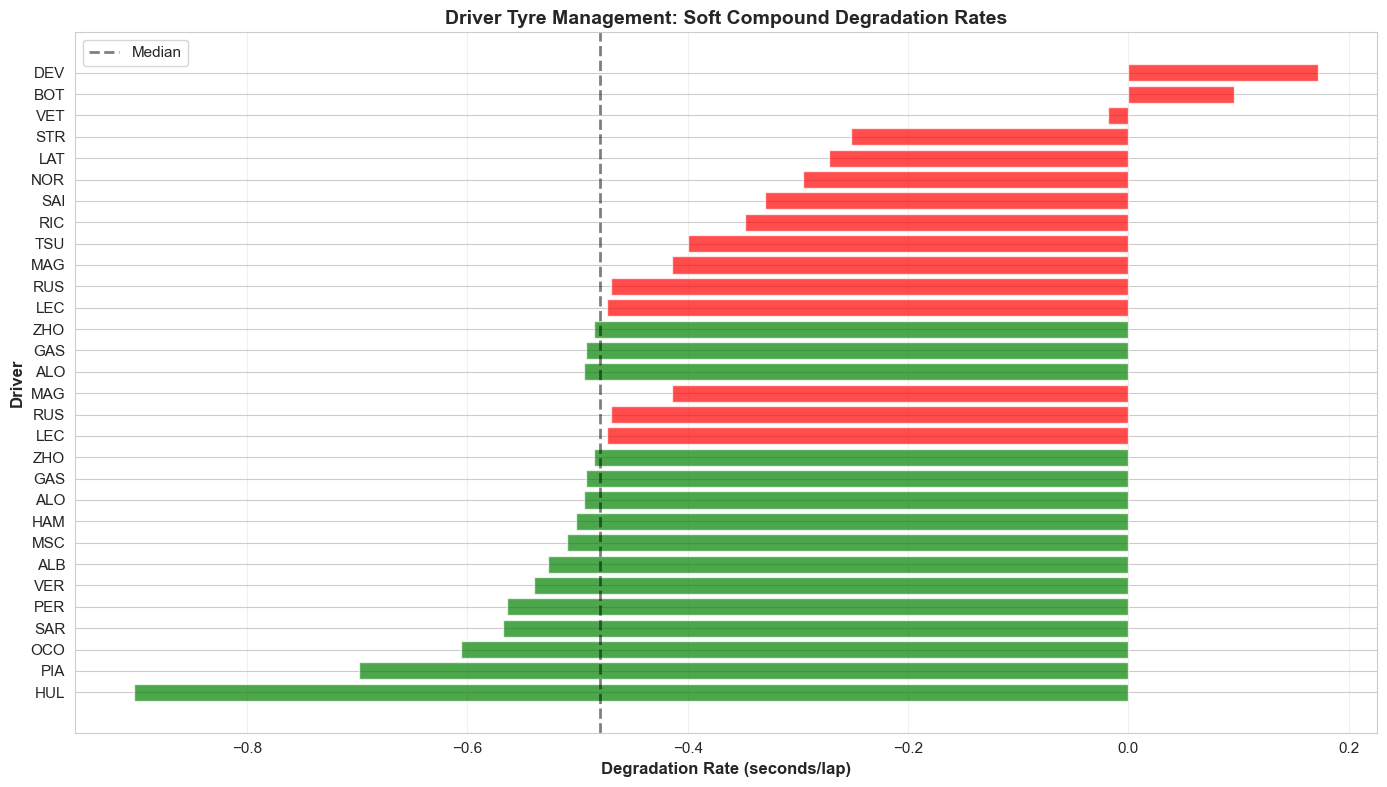

In [16]:
# Visualize driver degradation rates
if len(driver_deg_df) > 0:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Top 15 and bottom 15 drivers
    top_bottom = pd.concat([driver_deg_df.head(15), driver_deg_df.tail(15)])
    
    colors = ['green' if x < driver_deg_df['Deg Rate (s/lap)'].median() else 'red' 
              for x in top_bottom['Deg Rate (s/lap)']]
    
    ax.barh(range(len(top_bottom)), top_bottom['Deg Rate (s/lap)'], color=colors, alpha=0.7)
    ax.set_yticks(range(len(top_bottom)))
    ax.set_yticklabels(top_bottom['Driver'])
    ax.set_xlabel('Degradation Rate (seconds/lap)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Driver', fontsize=12, fontweight='bold')
    ax.set_title('Driver Tyre Management: Soft Compound Degradation Rates', 
                fontsize=14, fontweight='bold')
    ax.axvline(driver_deg_df['Deg Rate (s/lap)'].median(), color='black', 
              linestyle='--', linewidth=2, label='Median', alpha=0.5)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()

## 6. Average Lap Time by Compound

Compare overall performance of different compounds (controlling for tyre age).

In [17]:
# Compare compounds at similar tyre ages (laps 5-15)
mid_life_tyres = valid_tyre_df[
    (valid_tyre_df['tyre_life'] >= 5) & 
    (valid_tyre_df['tyre_life'] <= 15)
]

compound_performance = mid_life_tyres.groupby('compound')['lap_time'].agg(['mean', 'std', 'count']).reset_index()
compound_performance = compound_performance[compound_performance['compound'].isin(main_compounds)]
compound_performance = compound_performance.sort_values('mean')

print("Average Lap Time by Compound (Laps 5-15 of stint)")
print("="*80)
print(compound_performance.to_string(index=False))

Average Lap Time by Compound (Laps 5-15 of stint)
    compound      mean       std  count
        SOFT 88.906868 10.904082   4776
      MEDIUM 90.102874 11.400758  11927
        HARD 90.416349 10.730852  12115
INTERMEDIATE 96.311924 11.426504   1748
         WET 98.685443  4.417809    203


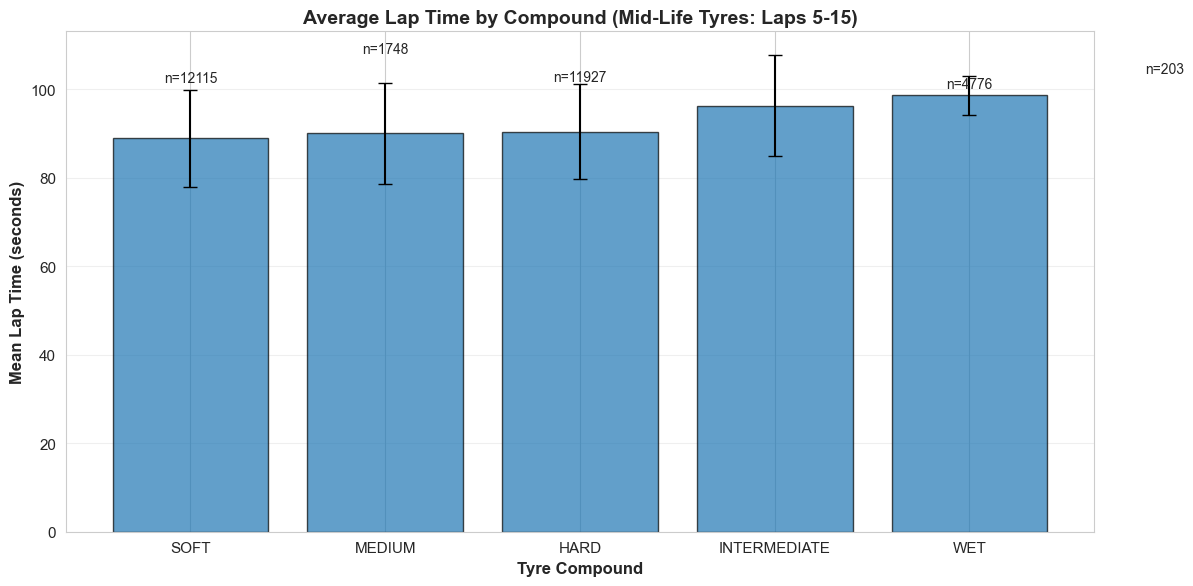

In [18]:
# Visualize compound performance
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(compound_performance['compound'], compound_performance['mean'], 
       yerr=compound_performance['std'], capsize=5, alpha=0.7, edgecolor='black')
ax.set_xlabel('Tyre Compound', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Lap Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Average Lap Time by Compound (Mid-Life Tyres: Laps 5-15)', 
            fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add sample sizes
for i, row in compound_performance.iterrows():
    ax.text(i, row['mean'] + row['std'] + 0.5, f"n={row['count']}", 
           ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Key Findings Summary

Summarize main insights about tyre strategy optimization.

In [19]:
print("\n" + "="*80)
print("KEY FINDINGS: Tyre Strategy Optimization (2022-2024)")
print("="*80)

print(f"\n1. DATA SUMMARY")
print(f"   - Valid tyre observations: {len(valid_tyre_df):,}")
print(f"   - Compounds analyzed: {', '.join(main_compounds)}")
print(f"   - Circuit types: {', '.join(valid_tyre_df['circuit_type'].unique())}")

print(f"\n2. DEGRADATION PATTERNS")
if len(deg_rate_df) > 0:
    for _, row in deg_rate_df.iterrows():
        print(f"   - {row['Compound']}: {row['Degradation Rate (sec/lap)']} sec/lap (R²={row['R²']})")

print(f"\n3. OPTIMAL STINT LENGTHS")
for compound in main_compounds:
    compound_stints = stint_data[stint_data['compound'] == compound]['stint_length']
    if len(compound_stints) > 0:
        print(f"   - {compound}: Mean={compound_stints.mean():.1f} laps, Median={compound_stints.median():.1f} laps")

print(f"\n4. CIRCUIT-SPECIFIC PATTERNS")
if len(circuit_compound) > 0:
    print(f"   - Compound usage varies significantly by circuit type")
    print(f"   - Street circuits may favor different strategies vs high-speed tracks")

print(f"\n5. DRIVER TYRE MANAGEMENT")
if len(driver_deg_df) > 0:
    best_manager = driver_deg_df.iloc[0]
    worst_manager = driver_deg_df.iloc[-1]
    print(f"   - Best tyre manager: {best_manager['Driver']} ({best_manager['Deg Rate (s/lap)']:.4f} s/lap)")
    print(f"   - Hardest on tyres: {worst_manager['Driver']} ({worst_manager['Deg Rate (s/lap)']:.4f} s/lap)")
    print(f"   - Range: {(worst_manager['Deg Rate (s/lap)'] - best_manager['Deg Rate (s/lap)']):.4f} s/lap difference")

print("\n" + "="*80)
print("\nNext Steps:")
print("- Fit mixed effects models with compound × tyre_life interactions")
print("- Include driver random slopes to quantify individual tyre management")
print("- Control for track temperature and weather conditions")
print("- Analyze optimal pit window timing based on degradation patterns")
print("- Cluster drivers into tyre management profiles (aggressive vs smooth)")
print("- Examine if driver style affects optimal compound strategy")
print("="*80)


KEY FINDINGS: Tyre Strategy Optimization (2022-2024)

1. DATA SUMMARY
   - Valid tyre observations: 62,691
   - Compounds analyzed: HARD, INTERMEDIATE, MEDIUM, SOFT, WET
   - Circuit types: technical, street, high_speed

2. DEGRADATION PATTERNS
   - HARD: -0.0766 sec/lap (R²=0.753)
   - INTERMEDIATE: -0.3440 sec/lap (R²=0.611)
   - MEDIUM: -0.2284 sec/lap (R²=0.943)
   - SOFT: -0.4269 sec/lap (R²=0.985)
   - WET: -0.8537 sec/lap (R²=0.917)

3. OPTIMAL STINT LENGTHS
   - HARD: Mean=27.0 laps, Median=27.0 laps
   - INTERMEDIATE: Mean=18.4 laps, Median=17.0 laps
   - MEDIUM: Mean=20.6 laps, Median=19.0 laps
   - SOFT: Mean=16.8 laps, Median=17.0 laps
   - WET: Mean=10.7 laps, Median=8.0 laps

4. CIRCUIT-SPECIFIC PATTERNS
   - Compound usage varies significantly by circuit type
   - Street circuits may favor different strategies vs high-speed tracks

5. DRIVER TYRE MANAGEMENT
   - Best tyre manager: HUL (-0.9024 s/lap)
   - Hardest on tyres: DEV (0.1720 s/lap)
   - Range: 1.0743 s/lap dif

## 8. Save Processed Data

Export cleaned data for future statistical modeling.

In [20]:
# Save tyre strategy data
output_file = 'data_rq3_tyre_strategy.csv'
valid_tyre_df.to_csv(output_file, index=False)
print(f"\nTyre strategy data saved to: {output_file}")
print(f"Rows: {len(valid_tyre_df):,}, Columns: {len(valid_tyre_df.columns)}")

# Save stint data
stint_output = 'data_rq3_stint_analysis.csv'
stint_data.to_csv(stint_output, index=False)
print(f"\nStint analysis data saved to: {stint_output}")
print(f"Rows: {len(stint_data):,}, Columns: {len(stint_data.columns)}")


Tyre strategy data saved to: data_rq3_tyre_strategy.csv
Rows: 62,691, Columns: 12

Stint analysis data saved to: data_rq3_stint_analysis.csv
Rows: 2,582, Columns: 6
